# AMERICAN PUT OPTION BLACK SCHOLES

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

In [2]:
#risk free rate
r = 0.05

#risk
sig = 0.2

#strike price
K = 1.

#time to maturity
T = 1.

#width of transformed S coordinate
w = 1.2

## Transformed Coordinate setup in $(\tau, x)$ and initial + boundary conditions

$$ \tau = T - t, \quad \tau (t=0) = T, \quad \tau (t=T) = 0 $$

$$ x = ln (\frac{S}{K}) , \quad x(S = K e^{-w}) = - w, \quad x(S = K e^{+w}) = w$$

$$ \partial_\tau f = \frac{1}{2} \sigma^2 \partial^2_x f + (r - \frac{1}{2}\sigma^2) \partial_x f - r f$$

$$ f(\tau =0, x) = max(K- K e^x, 0 )$$

$$ f(\tau, x = -w) = K - K e^{-w}$$

$$ f(\tau, x = w) = K(e^{-r \tau} - e^w)$$



$$ f(\tau, x) \geq K - Ke^{x} $$

Keeping the last constraint in mind, we solve the inhomogeneous PDE given below,

$$ \partial_{\tau} f = \frac{1}{2} \sigma^2 \partial^2_x f + (r - \frac{1}{2}\sigma^2) \partial_x f - rf + \lambda \cdot max(0, K - Ke^x - f), \quad \lambda = 50 r$$

In [3]:
lam = 50.*r

## Load in Chebyshev polynomials and match to initial data

In [4]:
n = 50

diff = np.loadtxt('diffmatrix100.txt')[0:n,0:n]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [5]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), 2*n))


In [6]:
# transform to two numerical coordinates

def xnum_to_xleft(xnum):
    return (xnum - 1.)*(w/2) 

def xnum_to_xright(xnum):
    return (xnum + 1.)*(w/2)

In [7]:
def get_coeff(n, f, xnum_to_x):

    xcol = np.cos(np.pi*np.linspace(0, n-1, n)/(n-1))
    x = xnum_to_x(xcol)

    L = np.zeros((n,n))
    R = np.zeros(n)

    for i in range(0,n):
        for k in range(0,n):
            L[i, k ] = chebyshevs[k](xcol[i])
            R[i] = f(x[i])
    
    c = np.linalg.solve(L, R)
    return c



In [8]:
# match to initial data using 2 cells

#first cell

fID_left = lambda x: K*(1. - np.exp(x))

c[0,0:n] = get_coeff(n, fID_left, xnum_to_xleft)

#second cell

fID_right = lambda x: 0. 

c[0,n:] = get_coeff(n, fID_right, xnum_to_xright)



In [9]:
# functions to plot data

xplot = np.linspace(-1,1,101)

def calc_u(c,x):
    sum = 0.0
    for i in range(len(c)):
        sum = sum + c[i]*chebyshevs[i](x)
    return sum

def plot_frame(tau_index):

    #left part
  
    plt.plot(xnum_to_xleft(xplot), calc_u(c[tau_index,0:n], xplot), c='blue')
       
    #right part
   
    plt.plot(xnum_to_xright(xplot), calc_u(c[tau_index,n:], xplot), c='blue')
       
    plt.axvline(x = 0, c='black', linewidth=1)
   
    plt.title('f(x) at '+r'$\tau=$ '+str(tau[tau_index]))
    plt.ylabel(r'$f$')
    plt.xlabel(r'$x$')
    plt.show()



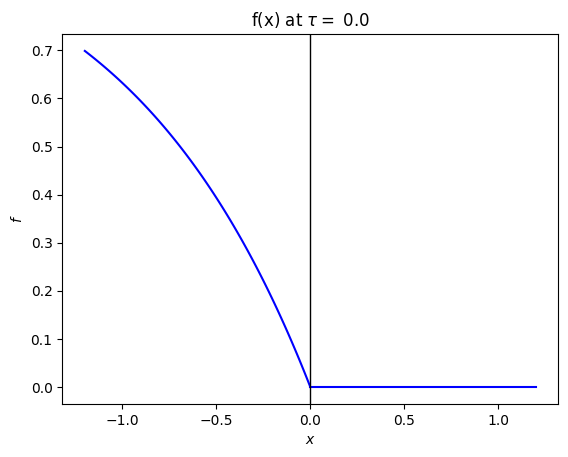

In [10]:
plot_frame(0)

## Transform PDE Problem to 2-chebyshev cell coordinates

$$ \partial_\tau f = \frac{1}{2} \sigma^2 (\frac{2}{w})^2 \partial^2_{xnum} f +(r - \frac{1}{2}\sigma^2) \frac{2}{w}\partial_{xnum} f - rf + \lambda \cdot max(0, K - K e^x - f)$$

$$ f(\tau, xnumleft =+1)  - f(\tau, xnumright = -1)  = 0$$

$$ \frac{2}{w}\partial_{xnumleft} f(\tau, xnumleft =+1) - \frac{2}{w}\partial_{xnumright} f(\tau, xnumright =-1) = 0$$

$$ f(\tau, xnumleft=-1) - K(1 - e^{-w}) = 0$$

$$ f(\tau, xnumright = 1) - K(e^{-r \tau} - e^w) = 0 $$

## Method of Lines Solution with SDIRK

In [11]:
c1 = 1/4
c2 = 0.
c3 = 1/2
c4 = 1.
c5 = 1.

a11 = 1/4
a21 = -1/4
a22 = 1/4
a31 = 1/8
a32 = 1/8
a33 = 1/4
a41 = -3/2
a42 = 3/4
a43 = 3/2
a44 = 1/4
a51 = 0.
a52 = 1/6
a53 = 2/3
a54 = -1/12
a55 = 1/4

b1 = 0.
b2 = 1/6
b3 = 2/3
b4 = -1/12
b5 = 1/4

In [12]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(1, n-2, int(n-3/1 + 1))/(n-1))

#collocation matrices
Tcol = np.zeros((len(xcol),n))
for i in range(0, len(xcol)):
    Tcol[i,:] = calc_T_matrix(n, xcol[i])
    
Tdiffcol = np.matmul(Tcol, diff)
Tdiff2col = np.matmul(np.matmul(Tcol, diff), diff)


In [13]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    

    L = np.zeros((2*n, 2*n))
    R = np.zeros((2*n, 2*n))
    J = np.zeros((2*n))
        
    #prepare the matrices
    
###################################################################################################
  
    #left outermost

    L[0:len(xcol),0:n] = Tcol 
    R[0:len(xcol),0:n] = (1/2)*sig**2*(2/w)**2*Tdiff2col + (r - (1/2)*sig**2)*(2/w)*Tdiffcol + (-r)*Tcol
    
    #spring term
    for i in range(0, len(xcol)):
        if K*(1 - np.exp(xnum_to_xleft(xcol[i]))) - calc_u(c[0:n], xcol[i]) > 0:
            R[i,0:n] = lam*-Tcol[i,:]
            J[i] =  lam*K*(1 - np.exp(xnum_to_xleft(xcol[i])))

    row_count = len(xcol)    
    
#####################################################################################################################################
    
   
    #right outermost cell
    
    L[row_count:row_count + len(xcol),n:] = Tcol 
    R[row_count:row_count + len(xcol),n:] = (1/2)*sig**2*(2/w)**2*Tdiff2col + (r - (1/2)*sig**2)*(2/w)*Tdiffcol + (-r)*Tcol
    
    #spring term
    for i in range(0, len(xcol)):
        if K*(1 - np.exp(xnum_to_xright(xcol[i]))) - calc_u(c[n:], xcol[i]) > 0:
            R[row_count + i,n:] = lam*-Tcol[i,:]
            J[row_count + i] =  lam*K*(1 - np.exp(xnum_to_xright(xcol[i])))

    row_count = row_count + len(xcol)
    
#############################################################################################################################################
    
    #boundary conditions

    #left cell
    R[row_count, 0:n] = calc_T_matrix(n, -1.)
    #J[row_count] =  - K*(np.exp(-r*tau) - np.exp(-w)) if it were a Euro put
    J[row_count] = - K*(1 - np.exp(-w))

    row_count = row_count + 1

    #right cell
    R[row_count, n:] = calc_T_matrix(n, +1.) 
    J[row_count] = 0.

    row_count = row_count + 1
    
    
####################################################################################################################################################
    

    #interface conditions
    TL = calc_T_matrix(n, +1.0)
    TR = calc_T_matrix(n, -1.0)
    TLdiff = np.matmul(TL, diff) 
    TRdiff = np.matmul(TR, diff) 

    #continuity
    
    R[row_count, 0:n] = -1*TL
    R[row_count, n:] = 1*TR
        
    row_count = row_count + 1
    
   
    #differentiability

    R[row_count, 0:n] = -(2/w)*TLdiff 
    R[row_count, n: ] = +(2/w)*TRdiff
    
    row_count = row_count + 1
    
    if key == 1:
        Lbar = L - R*(dtau)*(a11)
        Rbar = np.matmul(R, c) + J
        K1 = np.linalg.solve(Lbar,Rbar)
        return K1
    elif key == 2:
        Lbar = L - R*(dtau)*(a22)
        Rbar = np.matmul(R, c + dtau*K1*a21) + J
        K2 = np.linalg.solve(Lbar,Rbar)
        return K2
    elif key == 3:
        Lbar = L - R*(dtau)*(a33)
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) + J
        K3 = np.linalg.solve(Lbar,Rbar)
        return K3
    elif key == 4:
        Lbar = L - R*(dtau)*(a44)
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) + J
        K4 = np.linalg.solve(Lbar,Rbar)
        return K4
    elif key == 5:
        Lbar = L - R*(dtau)*(a55)
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) + J
        K5 = np.linalg.solve(Lbar,Rbar)
        return K5
    

In [14]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , 5)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))


0
The time is: 0.0
The average of the Chebychev coefficients is: 0.008013455938402076
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.008147510194984968
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.008153146124524726
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.008155446424779299
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.008156920615763145
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.00815762596293079
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.008158399157095854
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.008158986919934615
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.0081593491722933
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.00815961170434673


## Analysis

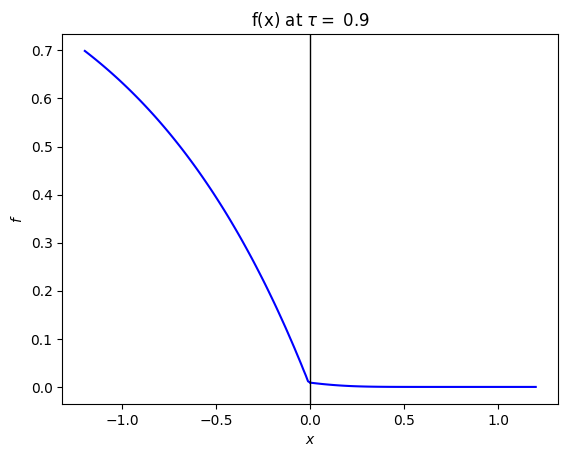

In [28]:
plot_frame(900)

In [16]:
def plot_coeff(tau_index):
    plt.plot(np.log10(np.abs(c[tau_index, 0:n])), c='red', label = 'left')
    plt.plot(np.log10(np.abs(c[tau_index, n:])), c='blue', label = 'right')
    plt.xlabel(r'$k$')
    plt.ylabel(r'$log_{10}|c_k|$')
    plt.legend()
    plt.show()

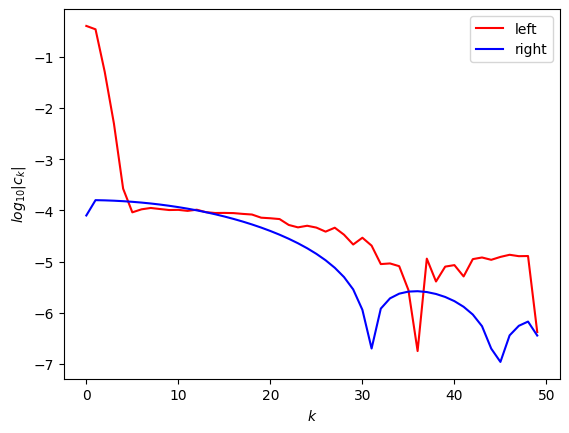

In [17]:
plot_coeff(1)

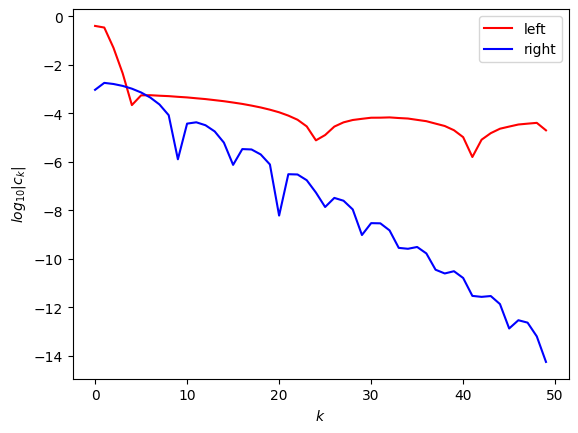

In [18]:
plot_coeff(100)

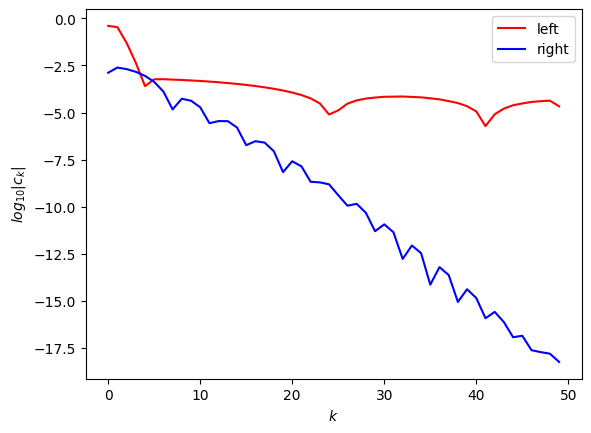

In [19]:
plot_coeff(300)

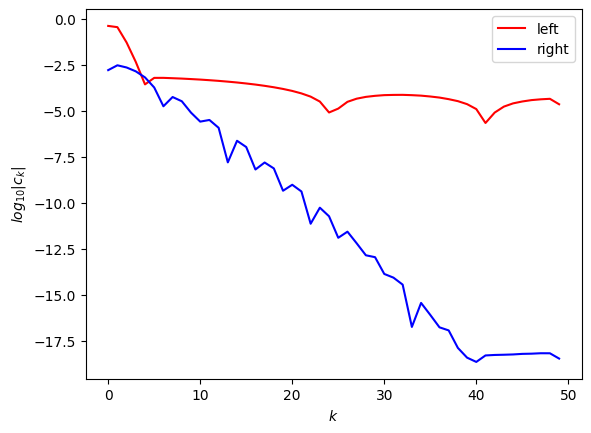

In [20]:
plot_coeff(600)

Fall of coefficients on the right is good, but left is consistently poor

In [21]:
def xleft_to_xnum(xleft):
    return (2/w)*xleft + 1.

def xright_to_xnum(xright):
    return (2/w)*xright - 1.


### Heatmap of solution fixed N and timestep

In [22]:

#pass in solution array

def american_put_heatmap(c):

    numerical_solution = np.zeros((len(tau), 2*len(xplot)))
    constraint = np.zeros((len(tau), 2*len(xplot)))
    
    for i in range(0, len(tau)):
        numerical_solution[i,:len(xplot)] = calc_u(c[i,0:n], xplot)
        constraint[i,:len(xplot)] = numerical_solution[i,:len(xplot)] - K*(1 - np.exp(xnum_to_xleft(xplot)))

        numerical_solution[i,len(xplot):] = calc_u(c[i,n:], xplot)
        constraint[i,len(xplot):] = numerical_solution[i,len(xplot):] - K*(1 - np.exp(xnum_to_xright(xplot)))
        
    return numerical_solution, constraint


In [23]:
num_american_put, american_put_constraint = american_put_heatmap(c)

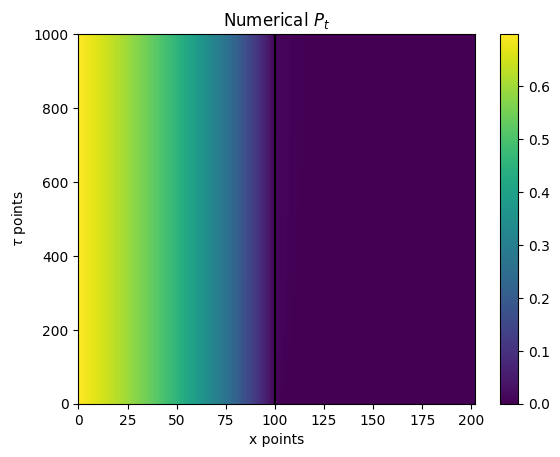

In [24]:
plt.pcolormesh(num_american_put)
plt.title('Numerical '+r'$P_t$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

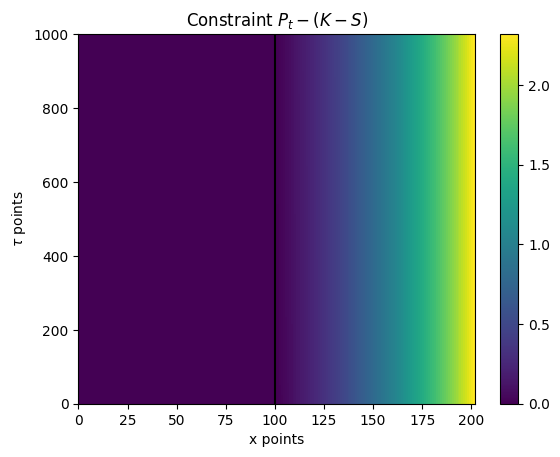

In [25]:
plt.pcolormesh(american_put_constraint)
plt.title('Constraint '+r'$P_t - (K - S)$')
plt.xlabel('x points')
plt.ylabel(r'$\tau$'+' points')
plt.axvline(x=100, c='black')
plt.colorbar()

In [26]:
np.min(american_put_constraint)

-0.00033231638289356324